In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)

In [3]:
val_datagen = ImageDataGenerator(rescale=1./255)


In [4]:
train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.


In [5]:
val_generator = val_datagen.flow_from_directory(
    'data/validation',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 2023 images belonging to 2 classes.


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
)

Epoch 1/10
251/251 [==============================] - 142s 558ms/step - loss: 0.6624 - accuracy: 0.5970 - val_loss: 0.6124 - val_accuracy: 0.6678
Epoch 2/10
251/251 [==============================] - 122s 484ms/step - loss: 0.6004 - accuracy: 0.6761 - val_loss: 0.5639 - val_accuracy: 0.7143
Epoch 3/10
251/251 [==============================] - 130s 517ms/step - loss: 0.5674 - accuracy: 0.7092 - val_loss: 0.5281 - val_accuracy: 0.7395
Epoch 4/10
251/251 [==============================] - 144s 574ms/step - loss: 0.5199 - accuracy: 0.7414 - val_loss: 0.5050 - val_accuracy: 0.7558
Epoch 5/10
251/251 [==============================] - 149s 593ms/step - loss: 0.4911 - accuracy: 0.7614 - val_loss: 0.4593 - val_accuracy: 0.7756
Epoch 6/10
251/251 [==============================] - 146s 582ms/step - loss: 0.4805 - accuracy: 0.7664 - val_loss: 0.4517 - val_accuracy: 0.7870
Epoch 7/10
251/251 [==============================] - 140s 559ms/step - loss: 0.4631 - accuracy: 0.7816 - val_loss: 0.4119 -

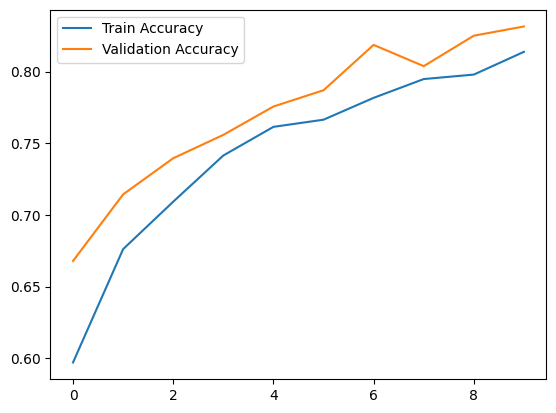

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()
